(1) Linear Regression (ydl + kq):  RMSE = 0.3506 | Log Loss = 0.4332
(2) Logistic Regression (ydl):      RMSE = 0.3438 | Log Loss = 0.3795
(3) Logistic Regression (ydl + kq): RMSE = 0.3433 | Log Loss = 0.3784


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


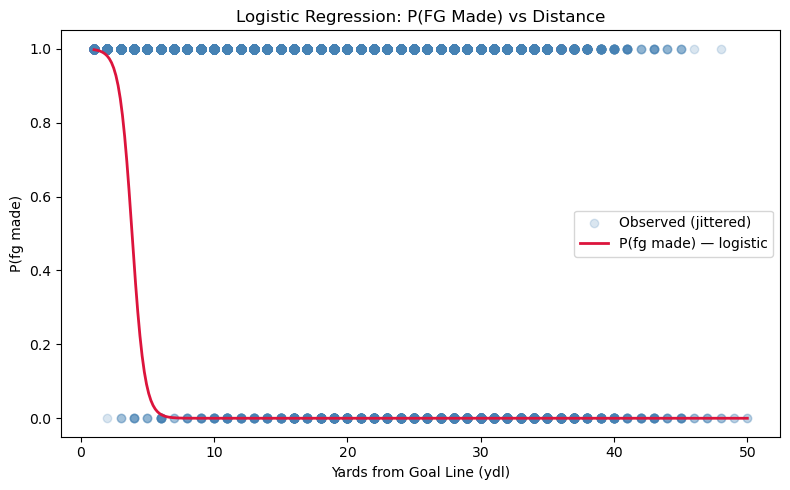

[[-2.13128444  0.24579084]] [8.13807549]


In [34]:
#Task 1

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, log_loss
import matplotlib.pyplot as plt
import math

# Load data
df = pd.read_csv("03_field-goals.csv")

X_ydl = df[["ydl"]]
df["log_ydl"] = np.log(df["ydl"])
X_log_ydl = df["log_ydl"]
X_both = df[["log_ydl", "kq"]]
y = df["fg_made"]

# Train-test split (70/30)
X_ydl_train, X_ydl_test, y_train, y_test = train_test_split(X_ydl, y, test_size=0.3, random_state=42)
X_both_train, X_both_test, _, _ = train_test_split(X_both, y, test_size=0.3, random_state=42)

# (1) Linear regression: ydl + kq -> fg_made
lr = LinearRegression()
lr.fit(X_both_train, y_train)
lr_pred = lr.predict(X_both_test)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_pred_clipped = np.clip(lr_pred, 1e-15, 1 - 1e-15)
lr_logloss = log_loss(y_test, lr_pred_clipped)
print(f"(1) Linear Regression (ydl + kq):  RMSE = {lr_rmse:.4f} | Log Loss = {lr_logloss:.4f}")

# (2) Logistic regression: log(ydl) -> fg_made
log1 = LogisticRegression()
log1.fit(np.log(X_ydl_train), y_train)
log1_pred_prob = log1.predict_proba(np.log(X_ydl_test))
log1_rmse = np.sqrt(mean_squared_error(y_test, log1_pred_prob[:, 1]))
log1_logloss = log_loss(y_test, log1_pred_prob)
print(f"(2) Logistic Regression (ydl):      RMSE = {log1_rmse:.4f} | Log Loss = {log1_logloss:.4f}")

# (3) Logistic regression: ydl + kq -> fg_made
log2 = LogisticRegression()
log2.fit(X_both_train, y_train)
log2_pred_prob = log2.predict_proba(X_both_test)
log2_rmse = np.sqrt(mean_squared_error(y_test, log2_pred_prob[:, 1]))
log2_logloss = log_loss(y_test, log2_pred_prob)
print(f"(3) Logistic Regression (ydl + kq): RMSE = {log2_rmse:.4f} | Log Loss = {log2_logloss:.4f}")

# Plot: P(fg made) vs ydl for model (2)
ydl_range = np.linspace(df["ydl"].min(), df["ydl"].max(), 300).reshape(-1, 1)
prob_range = log1.predict_proba(ydl_range)[:, 1]

plt.figure(figsize=(8, 5))
plt.scatter(df["ydl"], df["fg_made"], alpha=0.2, color="steelblue", label="Observed (jittered)", zorder=2)
plt.plot(ydl_range, prob_range, color="crimson", linewidth=2, label="P(fg made) — logistic")
plt.xlabel("Yards from Goal Line (ydl)")
plt.ylabel("P(fg made)")
plt.title("Logistic Regression: P(FG Made) vs Distance")
plt.legend()
plt.tight_layout()
plt.show()

#Model coefficients
print(log2.coef_, log2.intercept_)

#Interpreting coefficients: For every one unit increase in ydl, the log odds fall by 2.12; for every one unit increase
#in kicker quality, the log odds improve by 0.245

Log-loss on full dataset: 0.4918

Intercept (B0): 0.2269

Top 10 strongest teams by coefficient:
1163    4.469475
1222    4.244001
1345    4.211112
1235    3.546850
1314    3.380029
1397    3.357010
1120    3.322397
1266    3.231303
1228    3.170456
1376    3.154098
dtype: float64

Bottom 10 weakest teams by coefficient:
1290   -4.969308
1178   -4.928651
1440   -4.242535
1164   -4.212655
1237   -3.970453
1476   -3.855048
1223   -3.378812
1259   -3.243187
1384   -3.079511
1230   -3.063695
dtype: float64


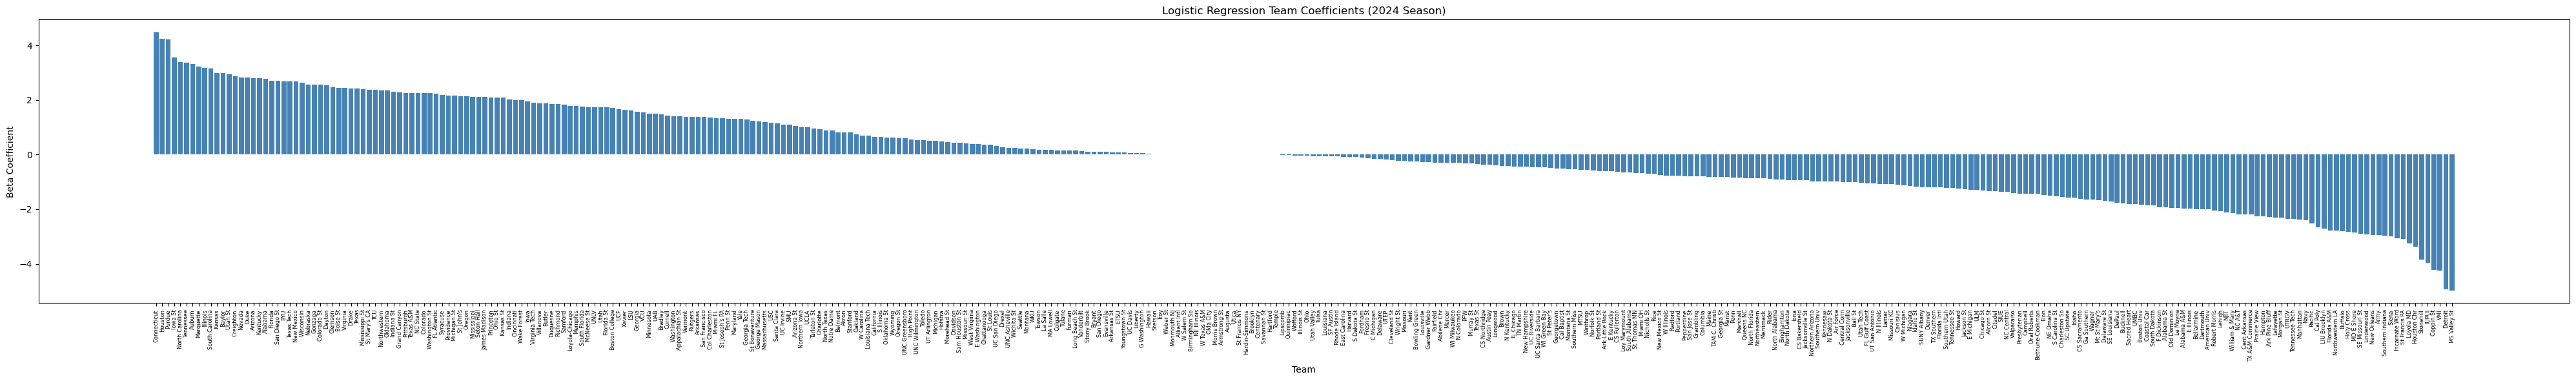

Probability that Purdue beats Uconn: 0.43576623812390325
129.48083456517477
77.2315071460746


In [43]:
#Question 2

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
import math


results = pd.read_csv("03_ncaab-results.csv")
teams   = pd.read_csv("03_ncaab-teams.csv")


# Build 2024 design matrix
results_2024 = results[results["Season"] == 2024].reset_index(drop=True)
all_team_ids = sorted(teams["TeamID"].unique())
matrix = pd.DataFrame(0, index=results_2024.index, columns=all_team_ids)

for idx, row in results_2024.iterrows():
    wid, lid, loc = row["WTeamID"], row["LTeamID"], row["WLoc"]
    if loc == "H":
        matrix.at[idx, wid] =  1
        matrix.at[idx, lid] = -1
    else:
        matrix.at[idx, wid] = -1
        matrix.at[idx, lid] =  1

# Add intercept column
matrix.insert(0, "Intercept", 1)
matrix.columns = matrix.columns.astype(str)

# Outcome vector
y = (results_2024["WLoc"] == "H").astype(int)

# Fit logistic regression
# fit_intercept=False because we've already added the intercept column manually
# C=1e9 to minimise regularisation so we're as close to pure MLE as possible
model = LogisticRegression(fit_intercept=False, C=1e9, max_iter=1000, solver="lbfgs")
model.fit(matrix, y)

# Report
y_pred_prob = model.predict_proba(matrix)
ll = log_loss(y, y_pred_prob)
print(f"Log-loss on full dataset: {ll:.4f}")

# Map coefficients back to team IDs / intercept
coef_series = pd.Series(model.coef_[0], index=matrix.columns)
print(f"\nIntercept (B0): {coef_series['Intercept']:.4f}")
print("\nTop 10 strongest teams by coefficient:")
print(coef_series.drop("Intercept").sort_values(ascending=False).head(10))
print("\nBottom 10 weakest teams by coefficient:")
print(coef_series.drop("Intercept").sort_values(ascending=True).head(10))

coefs = coef_series.drop("Intercept").reset_index()
coefs.columns = ["TeamID", "Beta"]
coefs["TeamID"] = coefs["TeamID"].astype(int)
coefs = coefs.merge(teams[["TeamID", "TeamName"]], on="TeamID", how="left")
coefs = coefs.sort_values("Beta", ascending=False).reset_index(drop=True)

#Visualizing the coefficients for each team
import matplotlib.pyplot as plt

plt.figure(figsize=(40, 6))
plt.bar(coefs["TeamName"], coefs["Beta"], color="steelblue")
plt.xticks(rotation=90, fontsize=6)
plt.xlabel("Team")
plt.ylabel("Beta Coefficient")
plt.title("Logistic Regression Team Coefficients (2024 Season)")
plt.tight_layout()
plt.show()

#Moneyline odds for Purdue vs Uconn
purdue = coef_series['1345']
uconn = coef_series['1163']

print("Probability that Purdue beats Uconn:", 1/(1+math.exp((-1)*(purdue - uconn))))
purdue_beats_uconn = 1/(1+math.exp((-1)*(purdue - uconn)))
uconn_beats_purdue = 1 - purdue_beats_uconn

print((100*uconn_beats_purdue)/(purdue_beats_uconn))
#Moneyline on Purdue is approx. +129.48

print(100*(purdue_beats_uconn)/uconn_beats_purdue)
#Moneyline on Uconn is approx. -77.23